# RM/PM EDA And Time-Series Evidence

Examines missingness, demand distributions, intermittency, seasonality, autocorrelation, scale variance and concentration before modeling.

In [1]:
from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

ROOT = Path.cwd()
if not (ROOT / "outputs").exists():
    ROOT = Path("Ai miroservices/modeling/project_operational_baseline").resolve()
OUT = ROOT / "outputs"
EVAL = OUT / "evaluator"
sns.set_theme(style="whitegrid")

In [2]:
demand = pd.read_csv(OUT / 'demand_history.csv.gz', parse_dates=['month'])
quality = pd.DataFrame({'missing': demand.isna().sum(), 'missing_pct': demand.isna().mean()*100})
display(quality[quality.missing.gt(0)])
display(demand.groupby('material_type').demand_units.describe(percentiles=[.5,.9,.95,.99]))

,missing,missing_pct


,count,mean,std,min,50%,90%,95%,99%,max
material_type,,,,,,,,,
packaging_material,2304.0,2108.985848,2510.631452,0.0,1295.218,5559.8448,7770.10465,10992.63543,13168.478
raw_material,3456.0,100.829741,182.401453,0.0,45.644,202.3340,406.26925,1009.42715,1818.913


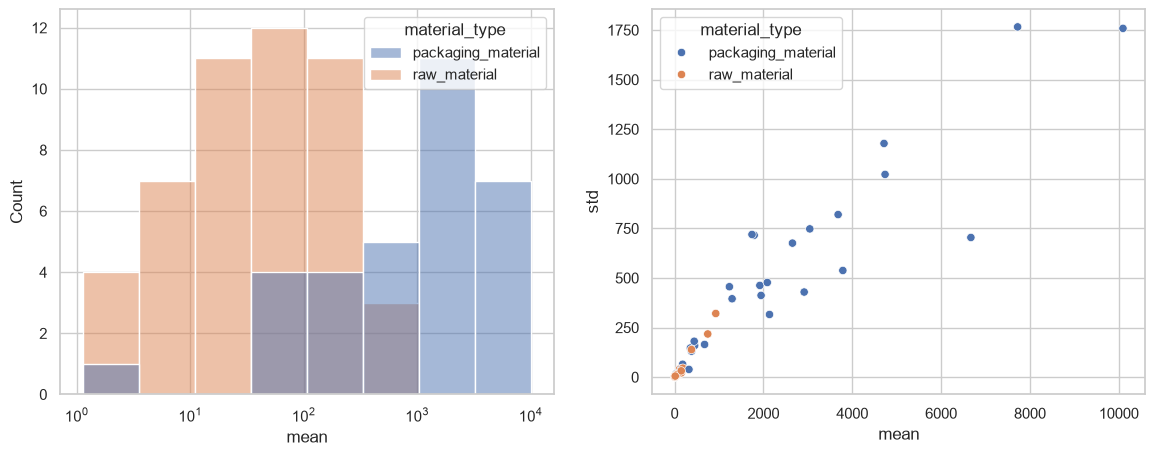

In [3]:
summary = demand.groupby(['material_id','material_code','material_type']).demand_units.agg(['mean','std',lambda s:(s==0).mean()]).reset_index()
summary.columns=['material_id','material_code','material_type','mean','std','zero_share']
fig, axes = plt.subplots(1,2,figsize=(14,5))
sns.histplot(data=summary,x='mean',hue='material_type',log_scale=True,ax=axes[0])
sns.scatterplot(data=summary,x='mean',y='std',hue='material_type',ax=axes[1]); plt.show()

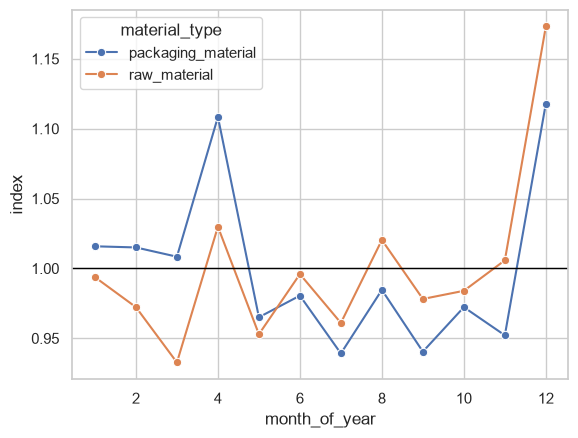

In [4]:
monthly = demand.groupby(['material_type','month']).demand_units.sum().reset_index()
monthly['month_of_year']=monthly.month.dt.month
season = monthly.groupby(['material_type','month_of_year']).demand_units.mean().reset_index()
season['index']=season.demand_units/season.groupby('material_type').demand_units.transform('mean')
sns.lineplot(data=season,x='month_of_year',y='index',hue='material_type',marker='o'); plt.axhline(1,color='black',lw=1); plt.show()

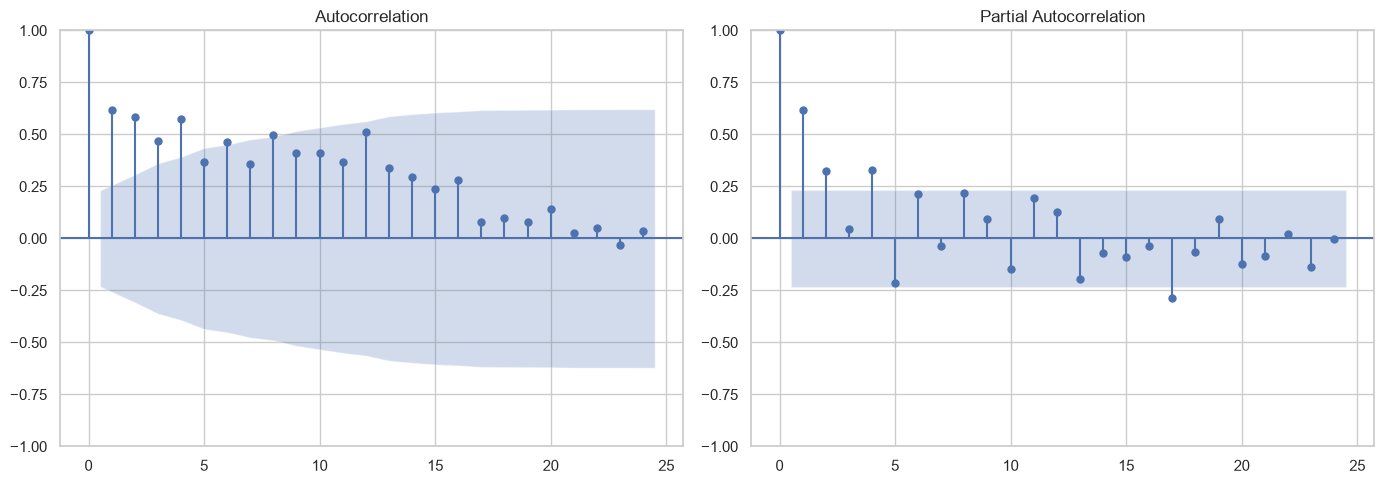

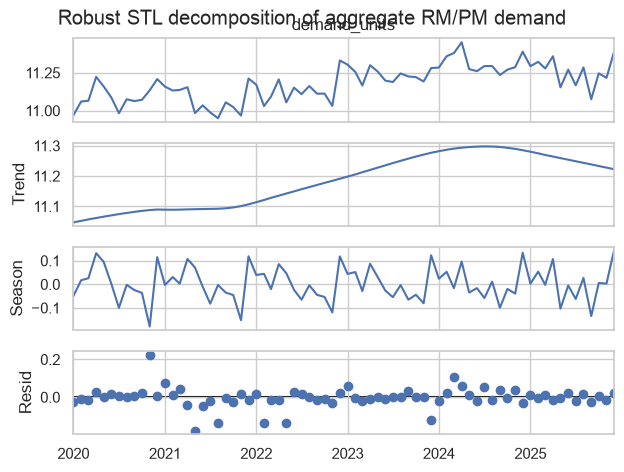

In [5]:
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import STL
aggregate=demand.groupby('month').demand_units.sum().sort_index()
fig,axes=plt.subplots(1,2,figsize=(14,5)); plot_acf(np.log1p(aggregate),lags=24,ax=axes[0]); plot_pacf(np.log1p(aggregate),lags=24,ax=axes[1],method='ywm'); plt.tight_layout(); plt.show()
decomposition=STL(np.log1p(aggregate),period=12,robust=True).fit(); decomposition.plot(); plt.suptitle('Robust STL decomposition of aggregate RM/PM demand'); plt.show()

In [6]:
spectral=pd.read_csv(EVAL/'spectral_evidence.csv')
display(spectral.groupby('material_type')[['annual_power_ratio','seasonal_strength','adf_p_value','kpss_trend_p_value']].agg(['mean','median']))
display(spectral[['material_code','annual_power_ratio','annual_red_noise_fdr_p_value','annual_seasonality_evidence','stationarity_evidence']].sort_values('annual_power_ratio',ascending=False).head(20))

annual_power_ratio           seasonal_strength            \
                                 mean    median              mean    median   
material_type                                                                 
packaging_material           0.094093  0.044225          0.155595  0.074721   
product                      0.314425  0.307470          0.483740  0.522014   
raw_material                 0.128861  0.085338          0.322021  0.331535   

                   adf_p_value               kpss_trend_p_value         
                          mean        median               mean median  
material_type                                                           
packaging_material    0.068515  1.260984e-09           0.096278    0.1  
product               0.247658  3.641841e-02           0.095190    0.1  
raw_material          0.179496  4.082667e-06           0.092763    0.1

,material_code,annual_power_ratio,annual_red_noise_fdr_p_value,annual_seasonality_evidence,stationarity_evidence
90,FG-0009,0.617829,0.021710,SUPPORTED,REJECTED
15,RM-0047,0.579999,0.021710,SUPPORTED,REJECTED
28,FG-0004,0.535994,0.021710,SUPPORTED,REJECTED
72,FG-0014,0.515346,0.021710,SUPPORTED,REJECTED
79,FG-0002,0.492726,0.021710,SUPPORTED,REJECTED
7,PM-0017,0.468483,0.021710,SUPPORTED,SUPPORTED
70,FG-0015,0.457666,0.021710,SUPPORTED,SUPPORTED
36,FG-0010,0.449474,0.021710,SUPPORTED,REJECTED
50,RM-0027,0.447322,0.021710,SUPPORTED,SUPPORTED
82,PM-0011,0.429745,0.021710,SUPPORTED,REJECTED


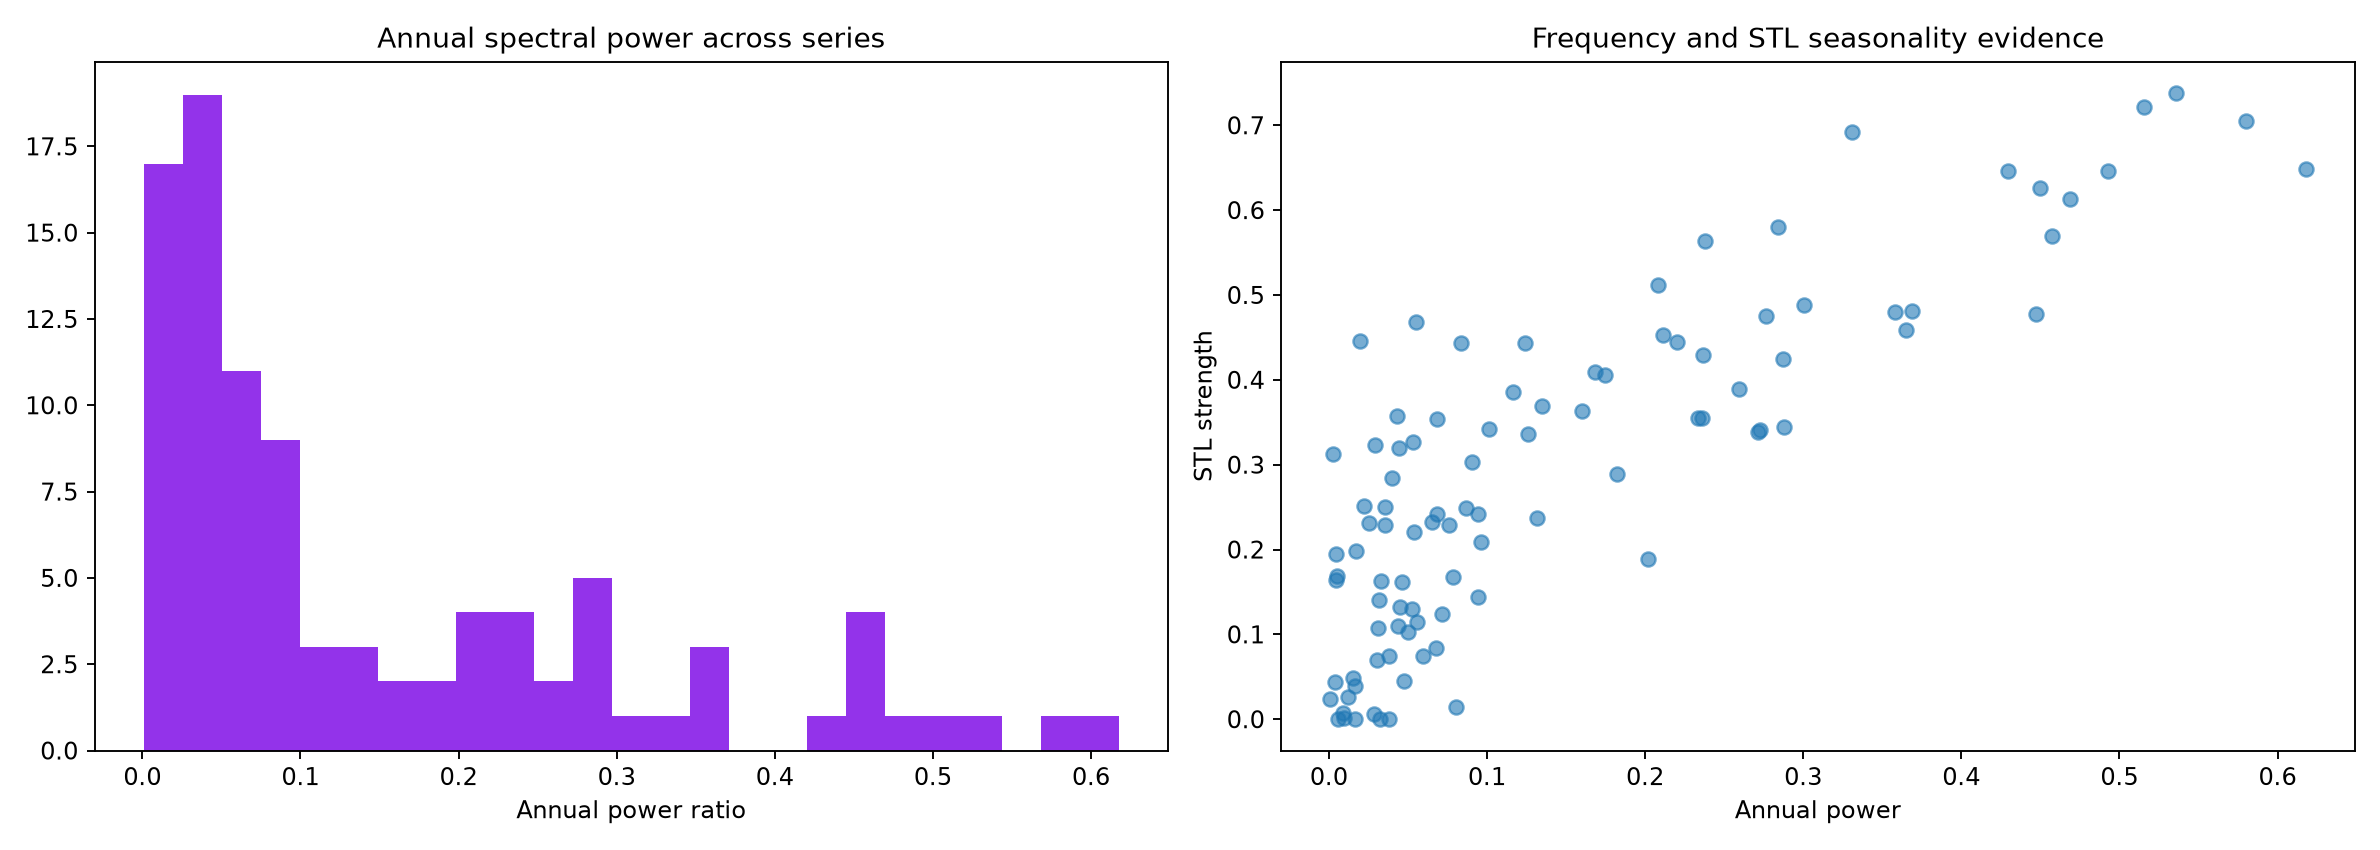

In [7]:
from IPython.display import Image, display
display(Image(filename=str(EVAL/'plots'/'04_frequency_domain_evidence.png')))

Annual/semiannual sine and cosine encodings remove the artificial December-to-January boundary. Frequency-domain summaries are calculated from each historical input window only; full-series periodograms are EDA evidence and are never injected into an earlier forecast origin.